In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

In [2]:
from IPython.display import Markdown, display

In [3]:
rng = np.random.default_rng(seed=42)

# Distribuições discretas, amostragem e incerteza

## Alternância entre duas construções

Considere a alternância entre duas construções possíveis em inglês:

1. **verb–object–particle:** *He picked the book up.*
2. **verb–particle–object:** *He picked up the book.*

Utilizaremos dados distribuídos por Stefan Th. Gries, referentes a um
experimento de Peters (2001). Cada observação registra qual das duas
construções foi produzida.

Antes de introduzir qualquer modelo probabilístico, começaremos descrevendo
o que foi efetivamente observado na amostra.

In [4]:
particle_url = (
    "https://raw.githubusercontent.com/"
    "jhlopesalves/eda_humanidades/refs/heads/main/"
    "encontro_10/data/vpcs.csv"
)

particle_df = pd.read_csv(
    particle_url,
    sep="\t",
)

particle_df.sample(
    n=5,
    random_state=42,
)

,CASE,CONSTRUCTION,GIVENNESS
114,115,verb-object-particle,new
278,279,verb-particle-object,new
237,238,verb-particle-object,given
57,58,verb-object-particle,given
72,73,verb-object-particle,given


Os nomes das colunas no arquivo original estão em letras maiúsculas. Para manter uma convenção consistente no código, vamos convertê-los para letras minúsculas.

In [5]:
particle_df.columns = (
    particle_df.columns
    .str.lower()
)

particle_df.sample(
    n=5,
    random_state=42,
)

,case,construction,givenness
114,115,verb-object-particle,new
278,279,verb-particle-object,new
237,238,verb-particle-object,given
57,58,verb-object-particle,given
72,73,verb-object-particle,given


### Estrutura dos dados

Cada linha corresponde a uma observação do experimento.

A coluna `CASE` identifica a observação, `CONSTRUCTION` registra a construção
produzida e `GIVENNESS` informa se o referente do objeto foi classificado como
`given` ou `new`.

Neste primeiro momento, concentraremos a análise em `CONSTRUCTION`.
Retornaremos a `GIVENNESS` posteriormente, quando precisarmos comparar grupos.

In [6]:
particle_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   case          397 non-null    int64
 1   construction  397 non-null    str  
 2   givenness     397 non-null    str  
dtypes: int64(1), str(2)
memory usage: 18.7 KB


### Frequências e proporções

Podemos resumir as duas categorias pelas frequências observadas e pelas
proporções que representam no conjunto de dados.

In [7]:
construction_summary = (
    particle_df["construction"]
    .value_counts()
    .rename_axis("construction")
    .reset_index(name="frequency")
)

construction_summary["proportion"] = (
    construction_summary["frequency"]
    / construction_summary["frequency"].sum()
)

construction_summary.round(3)

,construction,frequency,proportion
0,verb-particle-object,247,0.622
1,verb-object-particle,150,0.378


## Codificação binária da resposta

A variável `CONSTRUCTION` possui duas categorias. Definiremos uma variável
indicadora `VPO` por

$$
X_i =
\begin{cases}
1, & \text{se a observação } i \text{ corresponde a `verb-particle-object`} \\
0, & \text{se a observação } i \text{ corresponde a `verb-object-particle`.}
\end{cases}
$$

Com essa codificação, o valor `1` identifica a construção cuja proporção será
representada por $p$.

In [8]:
particle_df["vpo"] = (
    particle_df["construction"]
    == "verb-particle-object"
).astype(int)

particle_df.sample(
    n=5,
    random_state=42,
)

,case,construction,givenness,vpo
114,115,verb-object-particle,new,0
278,279,verb-particle-object,new,1
237,238,verb-particle-object,given,1
57,58,verb-object-particle,given,0
72,73,verb-object-particle,given,0


### Proporção amostral

Para uma variável indicadora, a média amostral é igual à proporção de
observações com valor `1`:


$$
\bar X
=
\frac{1}{n}\sum_{i=1}^{n}X_i
=
\frac{k}{n},
$$

em que $k$ é o número de observações com `VPO = 1`.

Representaremos essa proporção por $\hat p$.

In [9]:
n_observations = len(
    particle_df
)

k_vpo = particle_df["vpo"].sum()

p_hat = particle_df["vpo"].mean()

print(
    f"n observações: {n_observations:.3f}"
)

print(
    f"k observações: {k_vpo:.3f}"
)

print(f"média estimada: {p_hat:.3f}")

n observações: 397.000
k observações: 247.000
média estimada: 0.622


Temos:

$$
n = 397,
\qquad
k = 247,
$$

e, portanto,

$$
\hat p
=
\frac{247}{397}
\approx
0{,}622.
$$

Assim, aproximadamente 62,2% das observações da amostra correspondem a
`verb-particle-object`.

Até aqui, essa é uma afirmação **descritiva**: estamos resumindo os dados que
efetivamente observamos.

Mas uma amostra diferente, produzida pelo mesmo processo, não precisaria
apresentar exatamente 247 ocorrências de `verb-particle-object` em 397
observações.

A partir daqui, começaremos a representar matematicamente essa variabilidade.

### Modelo de Bernoulli

Para uma única observação, seja $X$ a variável indicadora definida acima.
Um modelo de Bernoulli é dado por

$$
X \sim \operatorname{Bernoulli}(p),
$$

com

$$
P(X=1)=p
\qquad\text{e}\qquad
P(X=0)=1-p.
$$

O parâmetro `$p$` representa a probabilidade de uma observação assumir o valor
`1`. Como esse parâmetro é desconhecido, utilizaremos a proporção amostral
$\hat p$ como estimativa.

Neste momento, utilizaremos a distribuição de Bernoulli como um **modelo
simplificado de referência** para representar uma escolha entre dois resultados
possíveis.

In [10]:
bernoulli_model = stats.bernoulli(
    p=p_hat,
)

### Função massa de probabilidade

Para uma variável aleatória discreta, a **função massa de probabilidade**
(PMF, *probability mass function*) associa uma probabilidade a cada valor
possível da variável.

No caso da Bernoulli, existem apenas dois valores possíveis: $0$ e $1$.

No SciPy, `.pmf(k)` retorna a probabilidade associada ao valor $k$.

In [11]:
print(
    f"P(VPO = 1): {bernoulli_model.pmf(1):.3f}"
)

print(
    f"P(VPO = 0): {bernoulli_model.pmf(0):.3f}"
)

P(VPO = 1): 0.622
P(VPO = 0): 0.378


Como utilizamos $p=\hat p$, o modelo atribui probabilidades próximas às
proporções observadas na amostra:

$$
P(X=1)\approx0{,}622
$$

e

$$
P(X=0)\approx0{,}378.
$$

Esses valores pertencem ao **modelo ajustado**; as contagens observadas em uma
nova amostra podem variar.

## Simulação a partir do modelo

Podemos utilizar o modelo ajustado para gerar novas observações aleatórias.

Para isso, faremos uma simplificação adicional: simularemos observações
independentes, todas com a mesma probabilidade $p=\hat p$.

Geraremos inicialmente uma amostra simulada com o mesmo tamanho da amostra
observada:

$$
n=397.
$$

No SciPy, `.rvs()` (*random variates*) gera valores aleatórios de uma
distribuição.

In [12]:
bernoulli_sample = bernoulli_model.rvs(
    size=n_observations,
    random_state=rng,
)

bernoulli_sample[:20]

array([0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0])

### Amostra observada e amostra simulada

Como `vpo` é uma variável indicadora, sua soma fornece o número de ocorrências
de VPO e sua média fornece a proporção de VPO.

Podemos calcular essas mesmas quantidades na amostra observada e na amostra
simulada.

In [13]:
simulated_vpo_count = bernoulli_sample.sum()
simulated_vpo_proportion = bernoulli_sample.mean()

pd.DataFrame(
    {
        "Amostra": [
            "Observada",
            "Simulada",
        ],
        "Ocorrências de VPO": [
            k_vpo,
            simulated_vpo_count,
        ],
        "Proporção de VPO": [
            p_hat,
            simulated_vpo_proportion,
        ],
    }
).round(3)

,Amostra,Ocorrências de VPO,Proporção de VPO
0,Observada,247,0.622
1,Simulada,245,0.617


A amostra observada e a amostra simulada possuem o mesmo tamanho, e a simulação
utilizou o mesmo valor de $p$ estimado nos dados observados.

Mesmo assim, as duas amostras não precisam apresentar exatamente a mesma
contagem nem a mesma proporção de VPO.

O parâmetro utilizado pelo modelo permaneceu fixo:

$$
p=\hat p\approx0{,}622.
$$

O que mudou foi a **realização aleatória da amostra**.

Essa variação entre amostras produzidas sob as mesmas condições é chamada de
**variabilidade amostral**.

### Contagem em uma amostra de Bernoulli

Para uma amostra de $n$ observações de Bernoulli, definiremos

$$
K=\sum_{i=1}^{n}X_i.
$$

Como cada $X_i$ assume apenas os valores 0 e 1, $K$ corresponde ao número de
observações com `VPO = 1`.

### Amostras repetidas

Mantendo $n$ e $p$ fixos, podemos gerar várias amostras independentes do mesmo
modelo.

Cada amostra produzirá:

- uma contagem de VPO, $K$;
- uma proporção de VPO,

$$
\hat p = \frac{K}{n}.
$$

Embora os parâmetros utilizados na simulação permaneçam os mesmos, essas
estatísticas podem variar de uma amostra para outra.

In [14]:
n_simulations = 10

repeated_bernoulli_samples = bernoulli_model.rvs(
    size=(
        n_simulations,
        n_observations,
    ),
    random_state=rng,
)

print(repeated_bernoulli_samples.shape)

repeated_bernoulli_samples[:3, :10]

(10, 397)


array([[1, 1, 1, 1, 0, 0, 1, 0, 0, 1],
       [1, 1, 1, 1, 0, 0, 0, 1, 0, 1],
       [1, 0, 0, 0, 1, 1, 0, 1, 0, 1]])

A matriz possui 10 linhas e 397 colunas. Cada linha corresponde a uma amostra
simulada, e suas 397 posições contêm as observações de Bernoulli dessa amostra.

Como $K$ é a soma dos valores de uma amostra, podemos somar cada linha para
obter uma contagem de VPO para cada uma das dez amostras. No NumPy, essa
operação corresponde à soma ao longo das colunas, com `axis=1`.

In [15]:
simulated_vpo_counts = repeated_bernoulli_samples.sum(
    axis=1,
)

simulated_vpo_proportions = repeated_bernoulli_samples.mean(
    axis=1,
)

pd.DataFrame(
    {
        "Simulação": np.arange(
            1,
            n_simulations + 1,
        ),
        "Ocorrências de VPO": simulated_vpo_counts,
        "Proporção de VPO": simulated_vpo_proportions,
    }
).round(3)

,Simulação,Ocorrências de VPO,Proporção de VPO
0,1,248,0.625
1,2,242,0.610
2,3,256,0.645
3,4,240,0.605
4,5,266,0.670
5,6,240,0.605
6,7,249,0.627
7,8,250,0.630
8,9,253,0.637
9,10,253,0.637


As dez amostras foram geradas com os mesmos valores de $n$ e $p$, mas
produziram contagens e proporções diferentes.

O parâmetro utilizado pelo modelo permaneceu fixo:

$$
p \approx 0{,}622.
$$

Já a proporção calculada em cada amostra,

$$
\hat p,
$$

variou entre as simulações.

Essa distinção será fundamental daqui em diante:

- $p$ é um **parâmetro do modelo**;
- $\hat p$ é uma **estatística calculada a partir de uma amostra**.

A variabilidade de $\hat p$ entre amostras é um exemplo de
**variabilidade amostral**.

### Como $\hat p$ varia entre amostras?
Com apenas dez simulações, já conseguimos observar que $\hat p$ varia de uma
amostra para outra.

Podemos agora repetir o mesmo processo milhares de vezes.

Em cada repetição:

1. geramos uma nova amostra de $n=397$ observações;
2. calculamos a proporção de VPO, $\hat p$.

Se repetirmos esse processo 5.000 vezes, obteremos:

$$
\hat p_1,\hat p_2,\ldots,\hat p_{5000}.
$$

A distribuição desses valores simulados aproxima a **distribuição amostral**
de $\hat p$ sob o modelo utilizado.

In [16]:
n_simulations = 5_000

simulation_samples = bernoulli_model.rvs(
    size=(
        n_simulations,
        n_observations,
    ),
    random_state=rng,
)

simulated_vpo_proportions = simulation_samples.mean(
    axis=1,
)

pd.Series(
    simulated_vpo_proportions,
    name="Proporção de VPO",
).describe()

count    5000.000000
mean        0.622382
std         0.024000
min         0.539043
25%         0.607053
50%         0.622166
75%         0.637280
max         0.705290
Name: Proporção de VPO, dtype: float64

Os 5.000 valores de $\hat p$ representam resultados que poderíamos obter em
amostras repetidas sob o mesmo modelo.

O histograma abaixo não representa a distribuição das observações individuais
$X_i$. Ele representa a distribuição de uma **estatística**, $\hat p$, entre
amostras.

Essa é a ideia de uma distribuição amostral.

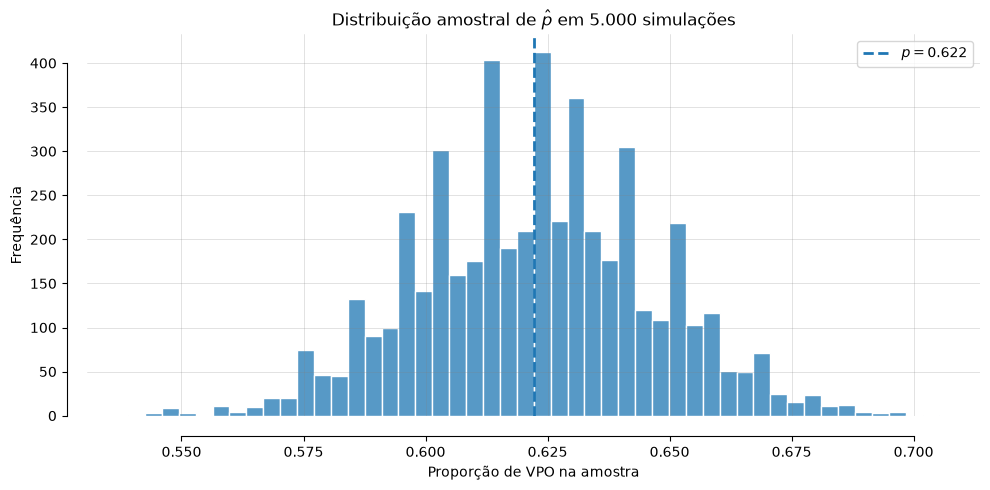

In [17]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

sns.histplot(
    x=simulated_vpo_proportions,
    bins="fd",
    edgecolor="white",
    ax=ax,
)

ax.axvline(
    p_hat,
    linestyle="--",
    linewidth=2,
    label=rf"$p = {p_hat:.3f}$",
)

ax.set(
    title="Distribuição amostral de $\\hat{p}$ em 5.000 simulações",
    xlabel="Proporção de VPO na amostra",
    ylabel="Frequência",
)

ax.legend()

ax.grid(True, alpha=0.4, linewidth=0.4, color="grey",
)

sns.despine(
    ax=ax, top=True, trim=True, offset=15,
)

plt.tight_layout()
plt.show()

A distribuição amostral mostra que $\hat p$ não assume sempre o mesmo valor.

Algumas amostras produzem estimativas um pouco maiores que $p$; outras,
estimativas um pouco menores. Entretanto, os valores tendem a se concentrar em
torno do parâmetro utilizado para gerar as amostras.

Portanto, uma estimativa obtida a partir de uma única amostra possui
**incerteza amostral**.

A próxima pergunta passa a ser:

> Quanto uma estatística como $\hat p$ tende a variar de uma amostra para
> outra?

Para responder a essa pergunta, precisaremos de uma medida da dispersão da
distribuição amostral.

## Distribuição binomial

Nas simulações anteriores, cada amostra contém $n$ observações binárias e $K$
representa o número de ocorrências de VPO:

$$
K = \sum_{i=1}^{n} X_i.
$$

Se as observações forem independentes, todas com a mesma probabilidade $p$ de
assumir o valor 1, então

$$
K \sim \operatorname{Binomial}(n,p).
$$

No modelo que utilizamos nas simulações:

- $n=397$;
- $p=\hat p\approx0{,}622$;
- $K$ é o número de ocorrências de VPO em cada amostra.

A distribuição binomial descreve teoricamente o mesmo processo que acabamos de
explorar por simulação.

In [18]:
binomial_model = stats.binom(
    n=n_observations,
    p=p_hat,
)

### Centro e variabilidade da distribuição amostral

Para uma variável binomial,
$$
K \sim \operatorname{Binomial}(n,p),
$$

o valor esperado e a variância são

$$
E(K)=np
$$

e

$$
\operatorname{Var}(K)=np(1-p).
$$

Como a proporção amostral pode ser escrita como

$$
\hat p=\frac{K}{n},
$$

sua distribuição amostral possui


$$
E(\hat p)=p
$$
e desvio-padrão

$$
\sqrt{\frac{p(1-p)}{n}}.
$$

O desvio-padrão de uma **distribuição amostral** recebe um nome específico:
**erro padrão** (*standard error*).

Portanto,

$$
SE(\hat p)
=
\sqrt{\frac{p(1-p)}{n}}.
$$


In [19]:
simulated_standard_error = (
    simulated_vpo_proportions.std(
        ddof=1
    )
)

model_standard_error = np.sqrt(
    p_hat
    * (1 - p_hat)
    / n_observations
)

print(
    f"Erro padrão nas simulações: "
    f"{simulated_standard_error:.4f}"
)

print(
    f"Erro padrão previsto pelo modelo: "
    f"{model_standard_error:.4f}"
)

Erro padrão nas simulações: 0.0240
Erro padrão previsto pelo modelo: 0.0243


As 5.000 simulações permitiram estimar empiricamente quanto $\hat p$ varia
entre amostras.

O modelo binomial permite calcular essa variabilidade diretamente.

Neste caso, os dois resultados são muito próximos: a distribuição amostral de
$\hat p$ possui desvio-padrão de aproximadamente $0{,}024$.

Em outras palavras, sob o modelo utilizado, proporções obtidas em amostras de
397 observações apresentam uma variabilidade amostral da ordem de alguns pontos
percentuais.

Esse erro padrão descreve a **precisão da estatística $\hat p$**: quanto menor
o erro padrão, menor tende a ser sua variação entre amostras repetidas.

In [20]:
sample_sizes = np.array(
    [100, 400, 1_600]
)

standard_errors = np.sqrt(
    p_hat
    * (1 - p_hat)
    / sample_sizes
)

pd.DataFrame(
    {
        "Tamanho da amostra": sample_sizes,
        "Erro padrão": standard_errors,
    }
).round(4)

,Tamanho da amostra,Erro padrão
0,100,0.0485
1,400,0.0242
2,1600,0.0121


O erro padrão depende do tamanho da amostra.

Como $n$ aparece dentro de uma raiz quadrada no denominador,


$$
SE(\hat p) \propto \frac{1}{\sqrt{n}}.
$$


Aumentar o tamanho da amostra tende, portanto, a reduzir a variabilidade
amostral e aumentar a precisão da estimativa.

O ganho, porém, não é linear: quadruplicar o tamanho da amostra reduz o erro
padrão aproximadamente pela metade.

## Bootstrap

Até aqui, utilizamos um modelo probabilístico para descrever a variabilidade de
$\hat p$ entre amostras.

Sob o modelo binomial, obtivemos:

$$
SE(\hat p)
=
\sqrt{\frac{p(1-p)}{n}}.
$$

Existe outra estratégia: utilizar a própria amostra observada para aproximar
como a estatística poderia variar sob novas amostragens.

Essa estratégia é chamada de **bootstrap**.

In [21]:
observed_vpo = particle_df["vpo"].to_numpy()

bootstrap_sample = rng.choice(
    observed_vpo,
    size=n_observations,
    replace=True,
)

bootstrap_p_hat = bootstrap_sample.mean()

bootstrap_p_hat

np.float64(0.6095717884130982)

### Distribuição bootstrap de $\hat p$

Cada reamostragem produz um novo valor de $\hat p^*$.

Depois de 5.000 reamostragens, obtemos:


$$
\hat p_1^*,
\hat p_2^*,
\ldots,
\hat p_{5000}^*.
$$


A distribuição desses valores é chamada de **distribuição bootstrap** da
estatística.

Ela é utilizada para aproximar a variabilidade que esperaríamos observar na
estatística entre amostras repetidas.

In [ ]:
observed_vpo = particle_df["vpo"].tolist()

n_bootstrap = 5_000

bootstrap_proportions_python = []

for _ in range(n_bootstrap):

    bootstrap_sample = [
        rng.choice(observed_vpo)
        for _ in range(n_observations)
    ]

    bootstrap_proportions_python.append(
        sum(bootstrap_sample)
        / n_observations
    )

In [ ]:
n_bootstrap = 5_000

bootstrap_samples = rng.choice(
    observed_vpo,
    size=(
        n_bootstrap,
        n_observations,
    ),
    replace=True,
)

bootstrap_proportions_numpy = bootstrap_samples.mean(
    axis=1,
)

bootstrap_proportions_numpy[:10]

array([0.62216625, 0.6070529 , 0.57934509, 0.68261965, 0.59949622,
       0.60453401, 0.63979849, 0.59445844, 0.63979849, 0.63224181])

In [ ]:
bootstrap_result = stats.bootstrap(
    data=(particle_df["vpo"].to_numpy(),),
    statistic=np.mean,
    n_resamples=5_000,
    method="percentile",
    rng=rng,
)

In [ ]:
bootstrap_comparison = pd.DataFrame(
    {
        "Método": [
            "Python",
            "NumPy",
            "SciPy",
        ],
        "Erro padrão": [
            np.std(
                bootstrap_proportions_python,
                ddof=1,
            ),
            bootstrap_proportions_numpy.std(
                ddof=1
            ),
            bootstrap_result.standard_error,
        ],
    }
)

bootstrap_comparison

,Método,Erro padrão
0,Python,0.024043
1,NumPy,0.024588
2,SciPy,0.024452


In [ ]:
bootstrap_df = pd.DataFrame(
    {
        "proportion": np.concatenate(
            [
                bootstrap_proportions_python,
                bootstrap_proportions_numpy,
                bootstrap_result.bootstrap_distribution,
            ]
        ),
        "method": np.repeat(
            [
                "Python",
                "NumPy",
                "SciPy",
            ],
            [
                len(bootstrap_proportions_python),
                len(bootstrap_proportions_numpy),
                len(bootstrap_result.bootstrap_distribution),
            ],
        ),
    }
)

bootstrap_df.sample(
    n=5,
    random_state=42,
)

,proportion,method
11499,0.609572,SciPy
6475,0.654912,NumPy
13167,0.624685,SciPy
862,0.612091,Python
5970,0.622166,NumPy


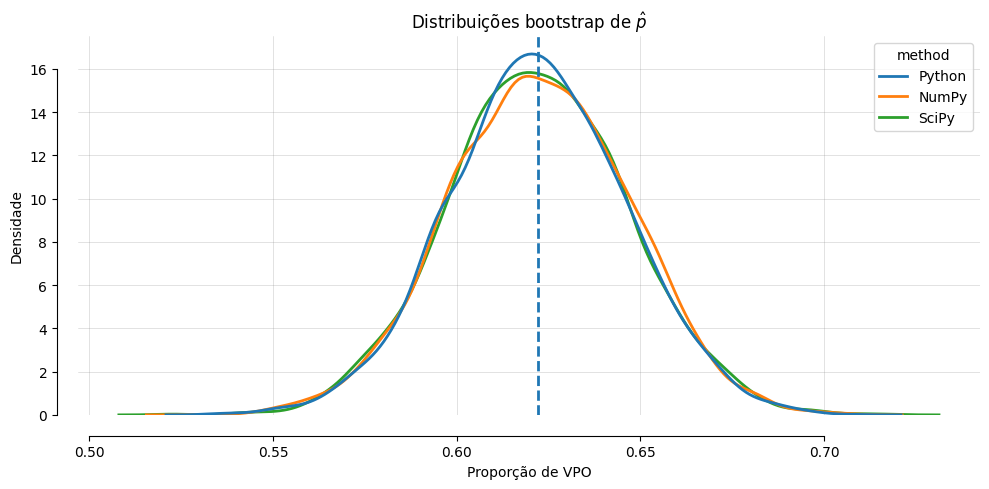

In [ ]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

sns.kdeplot(
    data=bootstrap_df,
    x="proportion",
    hue="method",
    common_norm=False,
    linewidth=2,
    ax=ax,
)

ax.axvline(
    p_hat,
    linestyle="--",
    linewidth=2,
)

ax.set(
    title="Distribuições bootstrap de $\\hat{p}$",
    xlabel="Proporção de VPO",
    ylabel="Densidade",
)

ax.grid(
    True,
    alpha=0.4,
    linewidth=0.4,
    color="grey",
)

sns.despine(
    ax=ax,
    top=True,
    trim=True,
    offset=15,
)

plt.tight_layout()
plt.show()

As três curvas foram produzidas por implementações diferentes do mesmo
procedimento:

- reamostragem explícita com Python;
- reamostragem vetorizada com NumPy;
- `scipy.stats.bootstrap()`.

As realizações aleatórias não são idênticas, portanto as curvas também não
precisam coincidir ponto a ponto. Entretanto, as três distribuições apresentam
praticamente a mesma posição, dispersão e forma.

A diferença está na **implementação computacional**, não no princípio
estatístico utilizado.

In [ ]:
bootstrap_result = stats.bootstrap(
    data=(observed_vpo,),
    statistic=np.mean,
    n_resamples=5_000,
    confidence_level=0.95,
    alternative="two-sided",
    method="BCa",
    paired=False,
    axis=0,
    rng=rng,
)

In [ ]:
bootstrap_summary = pd.DataFrame(
    {
        "statistic": ["mean"],
        "sample_size": [len(observed_vpo)],
        "observed_estimate": [p_hat],
        "n_resamples": [5_000],
        "confidence_level": [0.95],
        "method": ["BCa"],
        "alternative": ["two-sided"],
        "paired": [False],
        "standard_error": [
            bootstrap_result.standard_error
        ],
        "ci_low": [
            bootstrap_result.confidence_interval.low
        ],
        "ci_high": [
            bootstrap_result.confidence_interval.high
        ],
    }
)

bootstrap_summary.round(4).T

,0
statistic,mean
sample_size,397
observed_estimate,0.6222
n_resamples,5000
confidence_level,0.95
method,BCa
alternative,two-sided
paired,False
standard_error,0.0243
ci_low,0.5743


In [ ]:
bootstrap_distribution_df = pd.DataFrame(
    {
        "resample": np.arange(
            1,
            len(bootstrap_result.bootstrap_distribution) + 1,
        ),
        "proportion": (
            bootstrap_result.bootstrap_distribution
        ),
    }
)

bootstrap_distribution_df.head()

,resample,proportion
0,1,0.584383
1,2,0.596977
2,3,0.632242
3,4,0.632242
4,5,0.654912
